In [4]:
# --- 1. IMPORT LIBRARIES & LOAD DATASET ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Load dataset penguins
df = sns.load_dataset('penguins')

# Membersihkan data dari missing values agar plotting lancar
df = df.dropna()

# Cek informasi dataset awal
print("Ukuran Dataset:", df.shape)
print("\nTipe Data Kolom:\n", df.dtypes)
print("\nStatistik Deskriptif:\n", df.describe().round(2))

Ukuran Dataset: (333, 7)

Tipe Data Kolom:
 species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

Statistik Deskriptif:
        bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count          333.00         333.00             333.00       333.00
mean            43.99          17.16             200.97      4207.06
std              5.47           1.97              14.02       805.22
min             32.10          13.10             172.00      2700.00
25%             39.50          15.60             190.00      3550.00
50%             44.50          17.30             197.00      4050.00
75%             48.60          18.70             213.00      4775.00
max             59.60          21.50             231.00      6300.00


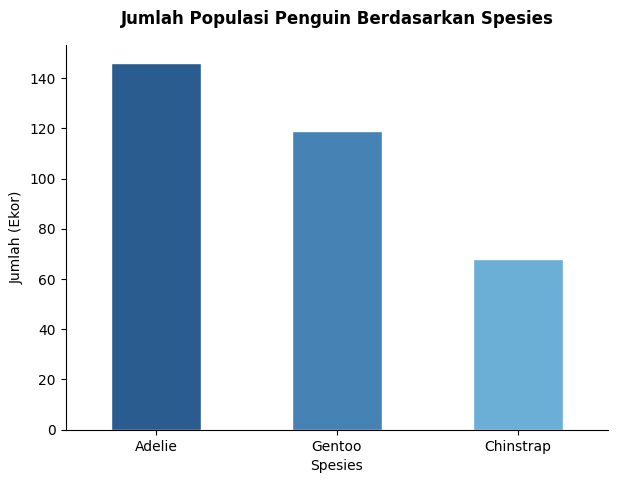


[ANALISIS GRAFIK 1: BAR CHART]
- What: Grafik batang ini menunjukkan jumlah sampel penguin untuk masing-masing spesies di mana Adelie merupakan yang terbanyak dengan 146 ekor, disusul Gentoo sebanyak 119 ekor, dan Chinstrap paling sedikit yaitu 68 ekor.
- So what: Informasi populasi ini krusial untuk memahami representasi data, karena ketimpangan jumlah sampel (seperti Chinstrap yang sedikit) dapat mendistorsi analisis jika kita berasumsi semua spesies memiliki kontribusi data yang sama.
- Now what: Perlu dipastikan apakah sedikitnya populasi Chinstrap mencerminkan kondisi riil di alam liar atau hanya keterbatasan dalam proses sampling data di lapangan.



In [5]:
# --- SEL 2: GRAFIK 1 (BAR CHART) ---
plt.figure(figsize=(7, 5))

# Menghitung populasi per spesies
species_counts = df['species'].value_counts()
species_counts.plot(kind='bar', color=['#2b5c8f', '#4682b4', '#6baed6'], edgecolor='white')

# Pengaturan judul dan label
plt.title('Jumlah Populasi Penguin Berdasarkan Spesies', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Spesies', fontsize=10)
plt.ylabel('Jumlah (Ekor)', fontsize=10)
plt.xticks(rotation=0)
sns.despine(left=False, bottom=False) # Menghapus border atas dan kanan

plt.show()

# --- SEL ANALISIS (WHAT, SO WHAT, NOW WHAT) ---
print("""
[ANALISIS GRAFIK 1: BAR CHART]
- What: Grafik batang ini menunjukkan jumlah sampel penguin untuk masing-masing spesies di mana Adelie merupakan yang terbanyak dengan 146 ekor, disusul Gentoo sebanyak 119 ekor, dan Chinstrap paling sedikit yaitu 68 ekor.
- So what: Informasi populasi ini krusial untuk memahami representasi data, karena ketimpangan jumlah sampel (seperti Chinstrap yang sedikit) dapat mendistorsi analisis jika kita berasumsi semua spesies memiliki kontribusi data yang sama.
- Now what: Perlu dipastikan apakah sedikitnya populasi Chinstrap mencerminkan kondisi riil di alam liar atau hanya keterbatasan dalam proses sampling data di lapangan.
""")

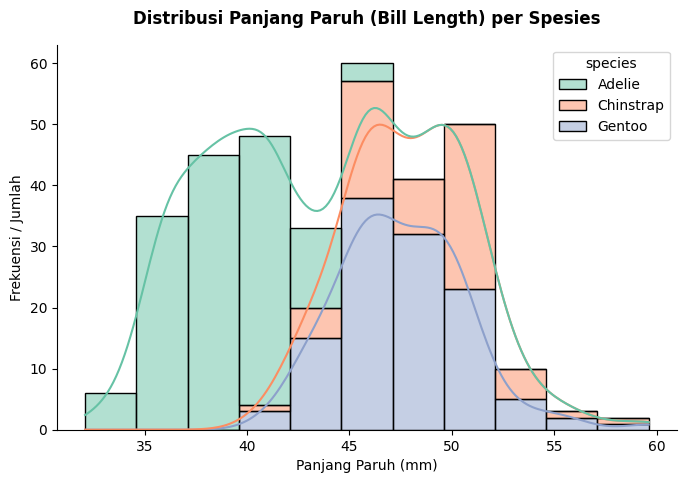


[ANALISIS GRAFIK 2: HISTOGRAM + KDE]
- What: Histogram ini memperlihatkan distribusi panjang paruh penguin yang memuncak di area kisaran 37-40 mm untuk Adelie, sedangkan Chinstrap dan Gentoo memiliki paruh yang lebih panjang di kisaran 45-50 mm.
- So what: Panjang paruh merupakan fitur morfologi pembeda yang sangat signifikan untuk mengklasifikasikan spesies penguin secara visual secara instan.
- Now what: Kita bisa memanfaatkan fitur panjang paruh (bill_length_mm) sebagai variabel prediktor utama jika ingin membangun model machine learning klasifikasi spesies.



In [6]:
# --- SEL 3: GRAFIK 2 (HISTOGRAM + KDE) ---
plt.figure(figsize=(8, 5))

# Plot distribusi panjang paruh
sns.histplot(data=df, x='bill_length_mm', hue='species', kde=True, palette='Set2', multiple='stack')

# Pengaturan judul dan label
plt.title('Distribusi Panjang Paruh (Bill Length) per Spesies', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Panjang Paruh (mm)', fontsize=10)
plt.ylabel('Frekuensi / Jumlah', fontsize=10)
sns.despine()

plt.show()

# --- SEL ANALISIS (WHAT, SO WHAT, NOW WHAT) ---
print("""
[ANALISIS GRAFIK 2: HISTOGRAM + KDE]
- What: Histogram ini memperlihatkan distribusi panjang paruh penguin yang memuncak di area kisaran 37-40 mm untuk Adelie, sedangkan Chinstrap dan Gentoo memiliki paruh yang lebih panjang di kisaran 45-50 mm.
- So what: Panjang paruh merupakan fitur morfologi pembeda yang sangat signifikan untuk mengklasifikasikan spesies penguin secara visual secara instan.
- Now what: Kita bisa memanfaatkan fitur panjang paruh (bill_length_mm) sebagai variabel prediktor utama jika ingin membangun model machine learning klasifikasi spesies.
""")

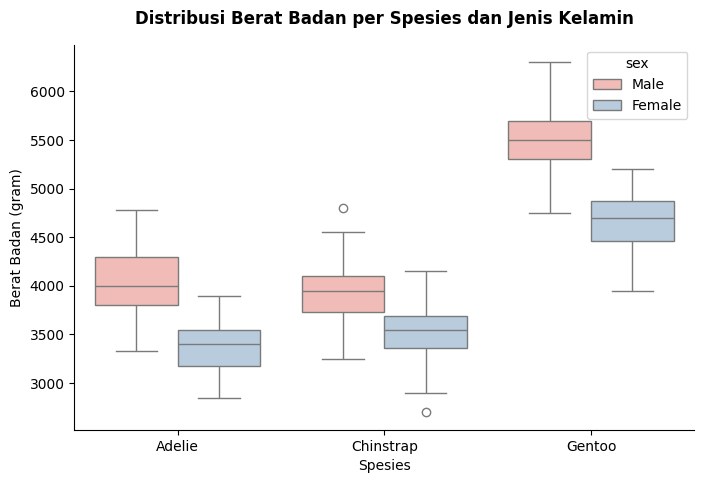


[ANALISIS GRAFIK 3: BOXPLOT]
- What: Boxplot menunjukkan bahwa penguin Gentoo memiliki berat badan yang jauh lebih besar (4,000-6,000 gram) dibanding Adelie dan Chinstrap (3,000-4,500 gram), dan penguin jantan secara konsisten lebih berat daripada penguin betina di semua spesies.
- So what: Terdapat pola dimorfisme seksual (perbedaan fisik jantan-betina) yang konsisten serta bukti bahwa Gentoo adalah spesies dengan ukuran fisik terbesar di antara ketiganya.
- Now what: Jika kita menemukan data penguin tanpa label jenis kelamin dengan berat di atas 5,000 gram, kita bisa berasumsi kuat bahwa itu adalah penguin Gentoo jantan.



In [7]:
# --- SEL 4: GRAFIK 3 (BOXPLOT) ---
plt.figure(figsize=(8, 5))

# Plot distribusi berat badan berdasarkan spesies dan jenis kelamin
sns.boxplot(data=df, x='species', y='body_mass_g', hue='sex', palette='Pastel1')

# Pengaturan judul dan label
plt.title('Distribusi Berat Badan per Spesies dan Jenis Kelamin', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Spesies', fontsize=10)
plt.ylabel('Berat Badan (gram)', fontsize=10)
sns.despine()

plt.show()

# --- SEL ANALISIS (WHAT, SO WHAT, NOW WHAT) ---
print("""
[ANALISIS GRAFIK 3: BOXPLOT]
- What: Boxplot menunjukkan bahwa penguin Gentoo memiliki berat badan yang jauh lebih besar (4,000-6,000 gram) dibanding Adelie dan Chinstrap (3,000-4,500 gram), dan penguin jantan secara konsisten lebih berat daripada penguin betina di semua spesies.
- So what: Terdapat pola dimorfisme seksual (perbedaan fisik jantan-betina) yang konsisten serta bukti bahwa Gentoo adalah spesies dengan ukuran fisik terbesar di antara ketiganya.
- Now what: Jika kita menemukan data penguin tanpa label jenis kelamin dengan berat di atas 5,000 gram, kita bisa berasumsi kuat bahwa itu adalah penguin Gentoo jantan.
""")

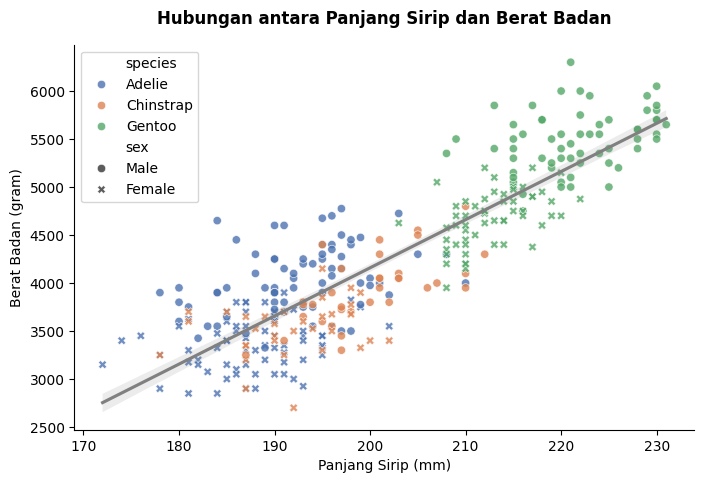


[ANALISIS GRAFIK 4: SCATTER PLOT]
- What: Scatter plot memperlihatkan hubungan linear positif yang sangat kuat antara panjang sirip (flipper_length_mm) dan berat badan (body_mass_g), di mana kelompok penguin Gentoo (warna hijau) berkumpul di area kanan atas.
- So what: Semakin panjang sirip seekor penguin, maka semakin besar pula massa atau berat badannya secara keseluruhan, mengindikasikan pertumbuhan fisik yang proporsional.
- Now what: Kita dapat membuat model regresi linear sederhana untuk memprediksi berat badan penguin hanya berdasarkan pengukuran panjang siripnya dengan tingkat akurasi yang diprediksi cukup tinggi.



In [9]:
# --- SEL 5: GRAFIK 4 (SCATTER PLOT) ---
plt.figure(figsize=(8, 5))

# Plot hubungan flipper length vs body mass
sns.scatterplot(data=df, x='flipper_length_mm', y='body_mass_g', hue='species', style='sex', palette='deep', alpha=0.8)
# Menambahkan garis tren linear (regresi) global berwarna abu-abu
sns.regplot(data=df, x='flipper_length_mm', y='body_mass_g', scatter=False, color='gray')

# Pengaturan judul dan label
plt.title('Hubungan antara Panjang Sirip dan Berat Badan', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Panjang Sirip (mm)', fontsize=10)
plt.ylabel('Berat Badan (gram)', fontsize=10)
sns.despine()

plt.show()

# --- SEL ANALISIS (WHAT, SO WHAT, NOW WHAT) ---
print("""
[ANALISIS GRAFIK 4: SCATTER PLOT]
- What: Scatter plot memperlihatkan hubungan linear positif yang sangat kuat antara panjang sirip (flipper_length_mm) dan berat badan (body_mass_g), di mana kelompok penguin Gentoo (warna hijau) berkumpul di area kanan atas.
- So what: Semakin panjang sirip seekor penguin, maka semakin besar pula massa atau berat badannya secara keseluruhan, mengindikasikan pertumbuhan fisik yang proporsional.
- Now what: Kita dapat membuat model regresi linear sederhana untuk memprediksi berat badan penguin hanya berdasarkan pengukuran panjang siripnya dengan tingkat akurasi yang diprediksi cukup tinggi.
""")